In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!nvidia-smi

Wed Apr 29 08:54:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os
#image data generator is the package to lable the images & it will automatically lable all the images

In [5]:
img = image.load_img(r"/content/drive/MyDrive/Colab Notebooks/training/happy/cs1.jpg")

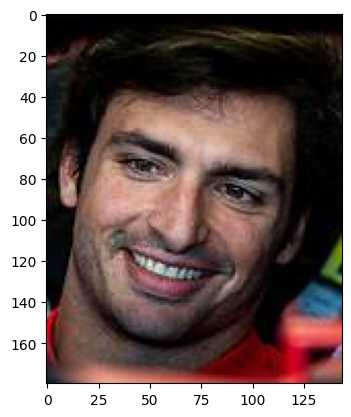

In [6]:
plt.imshow(img)

array([[[ 10,   9,  11],
        [  9,   8,  10],
        [  9,   8,  12],
        ...,
        [  0,   3,   0],
        [  0,   3,   0],
        [  0,   3,   0]],

       [[  8,   7,   9],
        [  8,   7,   9],
        [  7,   6,  10],
        ...,
        [  0,   3,   0],
        [  0,   3,   0],
        [  0,   3,   0]],

       [[  6,   5,   9],
        [  6,   5,   9],
        [  5,   4,   8],
        ...,
        [  0,   2,   0],
        [  0,   2,   0],
        [  0,   2,   0]],

       ...,

       [[ 49,  34,  18],
        [ 51,  38,  22],
        [ 57,  43,  31],
        ...,
        [ 82,  85, 123],
        [ 79,  86, 119],
        [ 79,  87, 117]],

       [[ 46,  32,  14],
        [ 46,  33,  17],
        [ 49,  36,  22],
        ...,
        [ 69,  73, 108],
        [ 66,  74, 104],
        [ 66,  74, 103]],

       [[ 46,  32,  14],
        [ 43,  31,  13],
        [ 43,  30,  16],
        ...,
        [ 60,  64,  99],
        [ 58,  66,  96],
        [ 58,  66,  95]]], dtype=uint8)
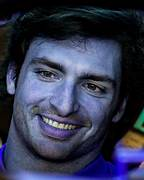

In [7]:
i1 = cv2.imread(r"/content/drive/MyDrive/Colab Notebooks/training/happy/cs1.jpg")
i1
# 3 dimension metrics are created for the image
# the value ranges from 0-255

In [8]:
i1.shape
# shape of your image height, weight, rgb

(180, 144, 3)

In [9]:
train = ImageDataGenerator(rescale = 1/255)
validataion = ImageDataGenerator(rescale = 1/255)
# to scale all the images i need to divide with 255
# we need to resize the image using 200, 200 pixel

In [10]:
train_dataset = train.flow_from_directory(r'/content/drive/MyDrive/Colab Notebooks/training',
                                         target_size = (200,200),
                                         batch_size = 3,
                                         class_mode = 'binary')
validataion_dataset = validataion.flow_from_directory(r'/content/drive/MyDrive/Colab Notebooks/validation',
                                          target_size = (200,200),
                                          batch_size = 3,
                                          class_mode = 'binary')

Found 10 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [11]:
train_dataset.class_indices

{'happy': 0, 'not happy': 1}

In [12]:
train_dataset.classes

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=int32)

In [13]:
# now we are applying maxpooling

model = tf.keras.models.Sequential([ tf.keras.layers.Conv2D(16,(3,3),activation = 'relu',input_shape = (200,200,3)),
                                    tf.keras.layers.MaxPool2D(2,2), #3 filtr we applied hear
                                    #
                                    tf.keras.layers.Conv2D(32,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    #
                                    tf.keras.layers.Conv2D(64,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    ##
                                    tf.keras.layers.Flatten(),
                                    ##
                                    tf.keras.layers.Dense(512, activation = 'relu'),
                                    #
                                    tf.keras.layers.Dense(1,activation= 'sigmoid')
                                    ]
                                    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(loss='binary_crossentropy',
              optimizer = tf.keras.optimizers.RMSprop(learning_rate = 0.001),
              metrics = ['accuracy']
              )

In [15]:
model_fit = model.fit(train_dataset,epochs=15)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 766ms/step - accuracy: 0.5000 - loss: 8.9885
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2000 - loss: 1.3809
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7000 - loss: 0.6009
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9000 - loss: 0.4692
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8000 - loss: 0.5082
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9000 - loss: 0.3917
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9000 - loss: 0.3126
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0892
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0398
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0234
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0149
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0106


In [16]:
dir_path = r'/content/drive/MyDrive/Colab Notebooks/testing'
for i in os.listdir(dir_path ):
    print(i)
    #img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
   # plt.imshow(img)
   # plt.show()

cs1.jpg
cs2.jpg
cs3.jpg
cs4.jpg
cs5.jpg
cl1.jpg
cl2.jpg
cl3.jpg
cl4.jpg
cl5.jpg


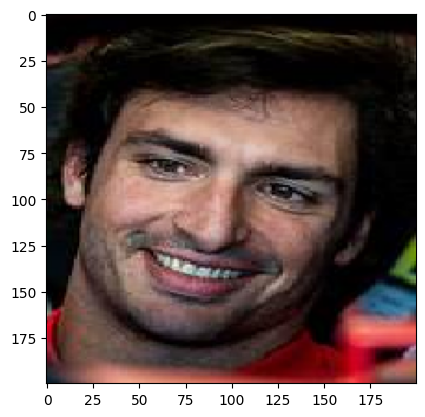

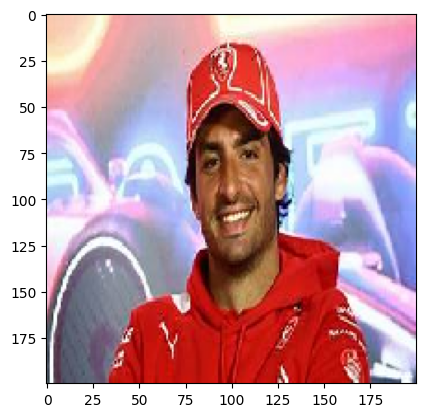

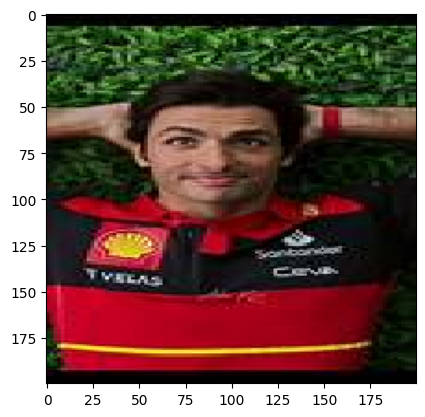

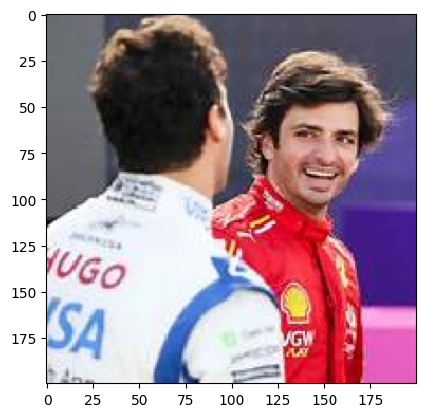

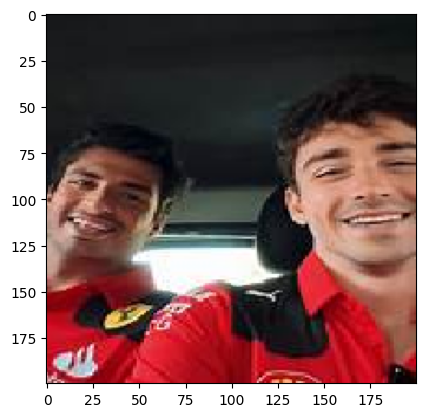

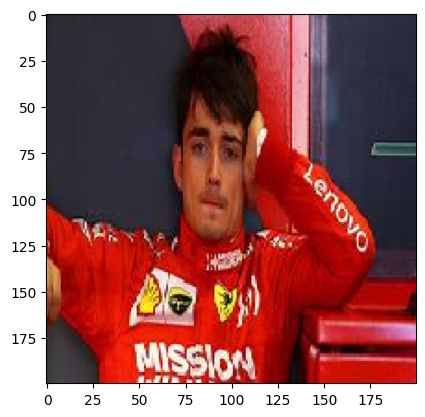

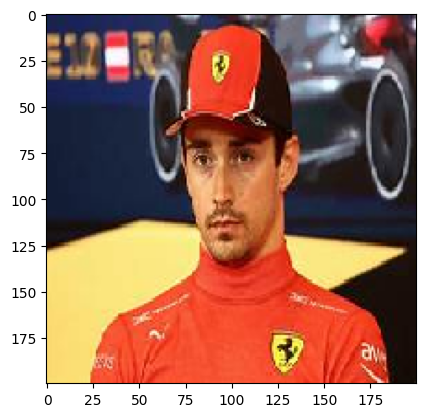

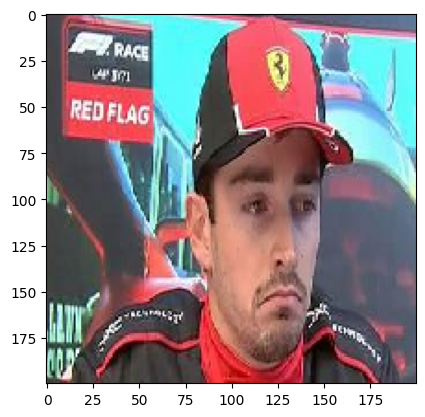

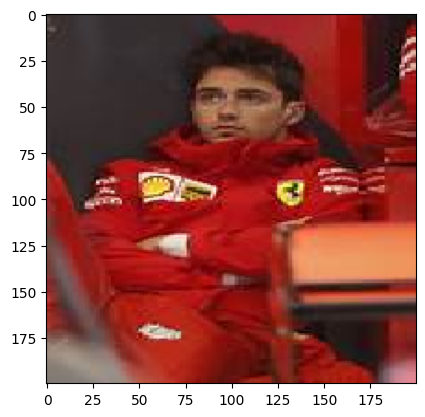

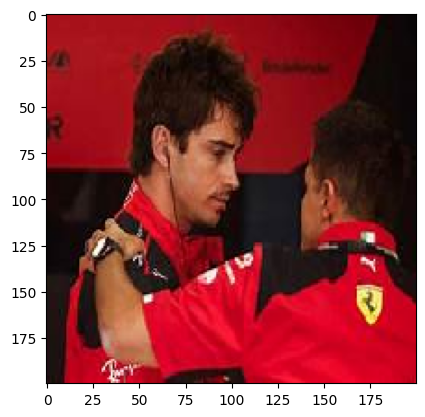

In [17]:
dir_path = r'/content/drive/MyDrive/Colab Notebooks/testing'
for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()

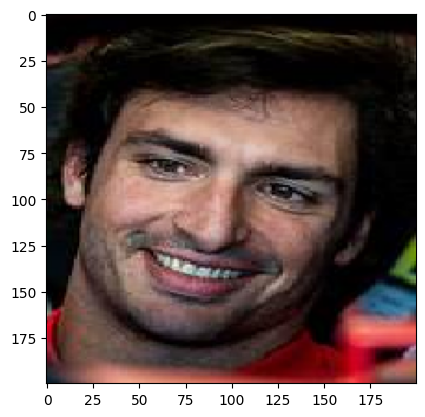

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
I am happy


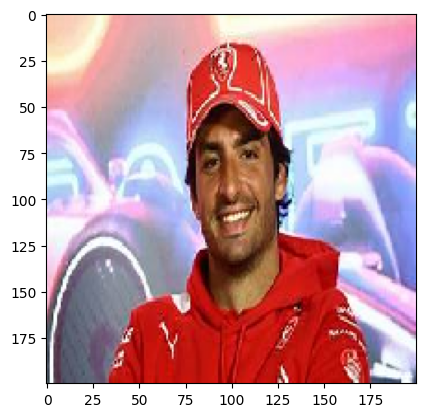

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
I am happy


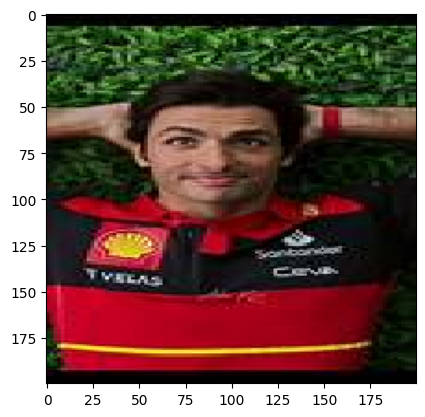

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
I am happy


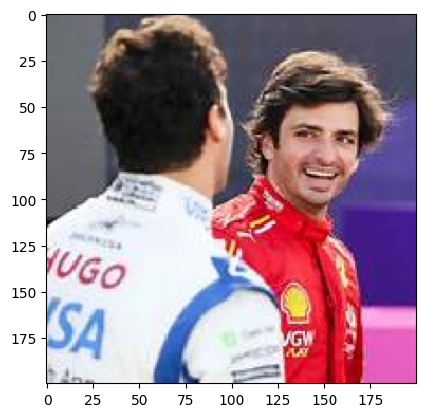

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
I am happy


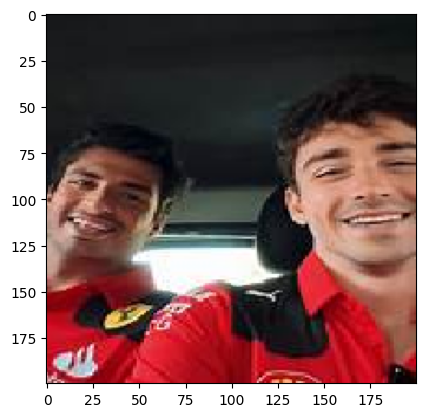

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
I am happy


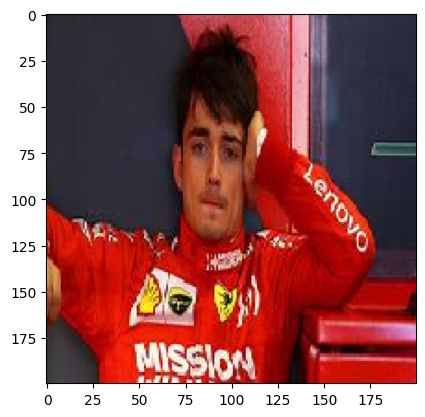

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
I am Not happy


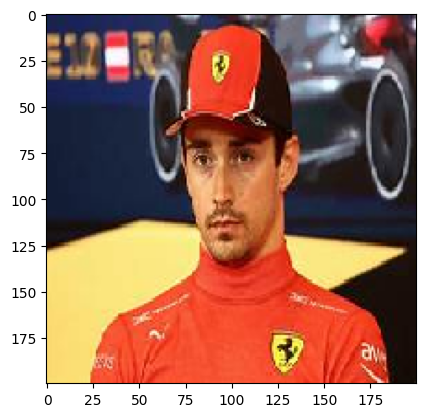

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
I am Not happy


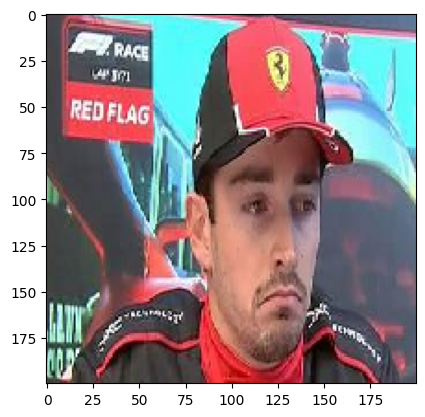

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
I am Not happy


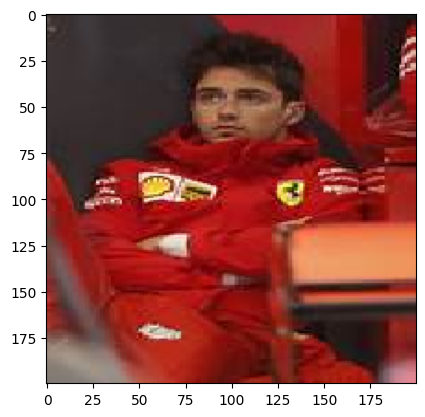

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
I am Not happy


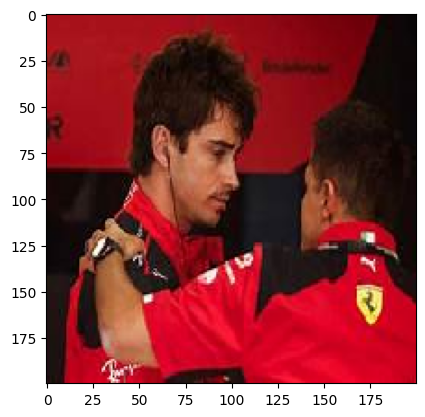

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
I am Not happy


In [18]:
dir_path = r'/content/drive/MyDrive/Colab Notebooks/testing'
for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()

    x= image.img_to_array(img)
    x=np.expand_dims(x,axis = 0)
    images = np.vstack([x])

    val = model.predict(images)
    if val == 0:
        print( 'I am happy')
    else:
        print('I am Not happy')

In [20]:
import gradio as gr
from PIL import Image
import numpy as np

def predict_mood(image):
  img = image.resize((200,200))
  x = np.array(img)
  x = np.expand_dims(x, axis=0)
  x=x/200.0
  val = model.predict(x)[0][0]
  if val < 0.5:
    return 'I am happy'
  else:
    return 'Not Happy'

In [21]:
iface = gr.Interface(fn=predict_mood,
                     inputs=gr.Image(type="pil", label = "upload an image"),
                     outputs=gr.Text(label="Predicted Mood"),
                     title = "Mood Classification (Happy/Not Happy)",
                     description="Upload an image to classify if the person is happy or not happy ."
                     )
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e88936cdc9d4a05bce.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
